# Homework 4: GPU programming for urban shadow analysis
### Cleaned notebook by Jamie Song for MUSA 6950

In this notebook, we will calculate the shadow distribution across time for a section of Northeast Philadelphia and export the results as an animated map.


First, we will prepare the modules.

In [1]:
!pip install pycuda
!pip install rasterio

In [2]:
from pycuda.compiler import SourceModule
import pycuda
from pycuda import gpuarray
from pycuda import compiler
import pycuda.autoinit             # PyCuda autoinit
import pycuda.driver as cuda       # PyCuda In, Out helpers
import os, os.path
import rasterio as rio
from osgeo import gdal
from osgeo.gdalconst import *
import numpy as np
import rasterio
import time
import math
import imageio                     # for animated gif
# Load the Drive helper and mount
from google.colab import drive
import matplotlib.cm as colormap   # Library to plot
import numpy                       # Fast math library
import matplotlib.image as mpimg       # reading images to numpy arrays
import matplotlib.pyplot as plt        # to plot any graph
import scipy.ndimage as ndi            # to determine shape centrality
# matplotlib setup

%matplotlib inline
from pylab import rcParams
rcParams['figure.figsize'] = (8, 8)      # setting default size of plots

print("pycuda installed and ready to use.")

print("%d device(s) found." % cuda.Device.count())
for ordinal in range(cuda.Device.count()):
    dev = cuda.Device(ordinal)
    print ("Device #%d: %s" % (ordinal, dev.name()))
print (cuda)

pycuda installed and ready to use.
1 device(s) found.
Device #0: Tesla T4
<module 'pycuda.driver' from '/usr/local/lib/python3.11/dist-packages/pycuda/driver.py'>


Next, we will mount to Google Drive to access the geotiff for the area of interest and save our files moving forward. We will also set the spatial boundaries for our GPU-assisted analysis.

In [3]:

# this will prompt for authorization
drive.mount('/content/drive')

# access geotiff in drive
dsm_file = "/content/drive/MyDrive/Colab Notebooks/data/row11-col17.tif"
os.path.exists(dsm_file)

dsm_dataset = rio.open(dsm_file)

dsm_bounds = dsm_dataset.bounds
dsm_img = dsm_dataset.read(1)
print('The dsm bound is:', dsm_bounds)


transform = dsm_dataset.transform

# the pixel width and height (scale) can be found as follows:
pixel_width = transform[0]  # scale in the x-direction
pixel_height = -transform[4]  # scale in the y-direction (usually negative)

# calculate a unified scale if needed (average or reciprocal)
scale = 1 / pixel_width  # this will give a scale factor


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The dsm bound is: BoundingBox(left=2712748.0, bottom=259294.0, right=2717948.0, top=264494.0)


In [4]:
dsm_dataset = rio.open(dsm_file)

dsm_bounds = dsm_dataset.bounds
dsm_img = dsm_dataset.read(1)
print('The dsm bound is:', dsm_bounds)


# prepare data
dsm = dsm_img.astype(np.float32)
height, width = dsm.shape
cell_size = 1.0  # assuming cell size is 1 meter, adjust according to DSM metadata

# allocate memory on the GPU
d_dsm = cuda.mem_alloc(dsm.nbytes)
d_slope = cuda.mem_alloc(dsm.nbytes)

# copy DSM data to GPU
cuda.memcpy_htod(d_dsm, dsm)

The dsm bound is: BoundingBox(left=2712748.0, bottom=259294.0, right=2717948.0, top=264494.0)


#### Compute the shadow distribution

Now, we are ready to calculate the shadow distribution for the hours of the day on August 1st, 2025 (8 AM to 6 PM).

In [5]:
# Define the CUDA kernel for the shadow calculation
kernel_shadow = """
#define PI 3.1415926

__global__ void calculate_shadow(float *dsm, bool *shadow, int width, int height, float cell_size, float sun_azimuth, float sun_elevation) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    // Check if the thread is within the bounds of the image
    if (x >= width || y >= height)
        return;

    int idx = y * width + x;

    // Convert sun azimuth and elevation to radians
    float azimuth_rad = sun_azimuth * 3.14159 / 180.0;
    float elevation_rad = sun_elevation * 3.14159 / 180.0;

    // Direction of the shadow ray based on sun azimuth
    float dx = sin(azimuth_rad);
    float dy = -cos(azimuth_rad);
    float dz = tan(elevation_rad);

    // Initial height at the current pixel
    float initial_height = dsm[idx];
    bool in_shadow = false;

    // Trace the shadow ray
    for (float t = cell_size; t < 2000.0f; t += cell_size) { // Limit tracing distance
        int x_offset = x + int(dx * t / cell_size);
        int y_offset = y + int(dy * t / cell_size);

        if (x_offset < 0 || x_offset >= width || y_offset < 0 || y_offset >= height)
            break;  // Out of bounds

        int offset_idx = y_offset * width + x_offset;

        // Calculate height along the ray
        float height_along_ray = initial_height + dz * t;

        // Check if there is a higher point along the path
        if (dsm[offset_idx] > height_along_ray) {
            in_shadow = true;
            break;
        }
    }

    // Store shadow result: 1 for shadow, 0 for no shadow
    shadow[idx] = in_shadow;
}
"""

Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_8.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_9.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_10.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_11.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_12.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_13.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_14.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_15.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_16.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_17.tif
Saved drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_18.tif


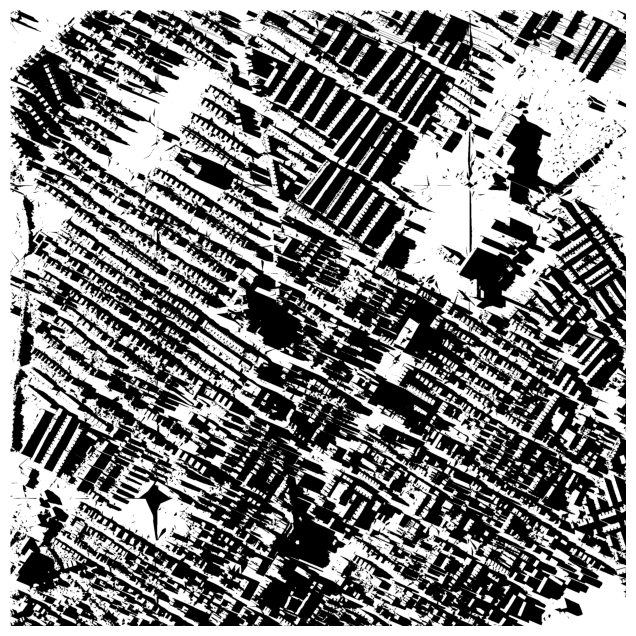

In [6]:
crs = "EPSG:2272"

# compile kernel
mod = SourceModule(kernel_shadow)
calculate_shadows = mod.get_function("calculate_shadow")

# prepare DSM dimensions and allocate GPU memory
height, width = dsm_img.shape
d_dsm = cuda.mem_alloc(dsm_img.nbytes)
d_shadow = cuda.mem_alloc(dsm_img.nbytes)
cuda.memcpy_htod(d_dsm, dsm_img)

block_size = (16, 16, 1)
grid_size = (int(np.ceil(width / block_size[0])), int(np.ceil(height / block_size[1])))

# define function to calculate shadow for given sun angles
def generate_shadow_frame(sun_azimuth, sun_elevation):
    shadow_result = np.zeros_like(dsm_img, dtype=bool)
    calculate_shadows(
        d_dsm, d_shadow, np.int32(width), np.int32(height),
        np.float32(cell_size), np.float32(sun_azimuth), np.float32(sun_elevation),
        block=block_size, grid=grid_size
    )
    cuda.memcpy_dtoh(shadow_result, d_shadow)
    return shadow_result.astype(np.uint8)

# define function to export geotiff
def save_geotiff(filename, array, transform, crs):
    with rasterio.open(
        filename, 'w',
        driver='GTiff',
        height=array.shape[0],
        width=array.shape[1],
        count=1,
        dtype=rasterio.uint8,
        transform=transform
    ) as dst:
        dst.write(array, 1)

# sun position approximation
hours = np.arange(8, 19)  # simulate from 8 AM to 6 PM
frames = []

for hour in hours:
    # approximate sun azimuth and elevation
    sun_azimuth = 93 + (hour - 8) * 20  # moves 20° per hour from East
    # estimate sun elevation dynamically
    if hour <= 12:
      sun_elevation = 35 + 10 * (hour - 8)  # Start at 30° at 8 AM, increase by 10° per hour
    else:
      sun_elevation = 75 - 10 * (hour - 12)  # Peak at 70° at noon, then decrease


    shadow_frame = generate_shadow_frame(sun_azimuth, sun_elevation)

    # invert black & white colors to accurately represent shadows
    shadow_frame = 255 - shadow_frame

    # export geotiff for each frame
    geotiff_filename = f"drive/MyDrive/Colab Notebooks/data/shadow_tifs/shadow_frame_{hour}.tif"
    save_geotiff(geotiff_filename, shadow_frame, transform, crs)
    print(f"Saved {geotiff_filename}")

    # prepare GIF visualization
    plt.imshow(shadow_frame, cmap='gray')
    plt.axis('off')
    frame_img = f"shadow_frame_{hour}.png"
    plt.savefig(frame_img, bbox_inches='tight', pad_inches=0)
    frames.append(imageio.v2.imread(frame_img))

# combine frames into an animated GIF
imageio.mimsave('drive/MyDrive/Colab Notebooks/data/shadow_distribution.gif', frames, fps=1)

# free GPU memory
d_dsm.free()
d_shadow.free()